## SIE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7, Tcmb0=0.0, Neff=3.04, m_nu=None, Ob0=0.0)

from ler.lens_galaxy_population import LensGalaxyParameterDistribution
from ler.utils import append_json, get_param_from_json

In [2]:
lens1 = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="sie_galaxy",
    lens_functions = dict(
            cross_section_based_sampler="rejection_sampler_partial",
            cross_section="cross_section_sie_feixu",
        ),
    directory="../interpolator_json",
    #create_new_interpolator=True,
)

lens2 = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="sie_galaxy",
    lens_functions = dict(
            cross_section_based_sampler="importance_sampler_partial",
            cross_section="cross_section_sie_feixu",
        ),
    directory="../interpolator_json",
    #create_new_interpolator=True,
)

lens3 = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="sie_galaxy",
    lens_functions = dict(
            cross_section_based_sampler="rejection_sampler_full",
            cross_section="cross_section_sie_feixu",
        ),
    directory="../interpolator_json",
    #create_new_interpolator=True,
)

lens4 = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="sie_galaxy",
    lens_functions = dict(
            cross_section_based_sampler="importance_sampler_full",
            cross_section="cross_section_sie_feixu",
        ),
    directory="../interpolator_json",
    #create_new_interpolator=True,
)


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ../interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ../interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ../interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ../interpolator_json/axis_ratio/rayleigh_2.json
using ler availabl

In [ ]:
param1 = lens1.sample_lens_parameters(20000)
# time = 3m 28.6s

sampling lens parameters with epl_shear_sl_parameters_rvs...


In [4]:
param2 = lens2.sample_lens_parameters(20000)
# time = 

sampling lens parameters with epl_shear_sl_parameters_rvs...


In [5]:
param3 = lens3.sample_lens_parameters(20000)
# time = 

sampling lens parameters with epl_shear_sl_parameters_rvs...


In [6]:
param4 = lens4.sample_lens_parameters(20000)
# time = 

sampling lens parameters with epl_shear_sl_parameters_rvs...


In [7]:
# keep only 'zs', 'zl', 'sigma'
param1 = {k: v for k, v in param1.items() if k in ['zs', 'zl', 'sigma', 'q']}
param2 = {k: v for k, v in param2.items() if k in ['zs', 'zl', 'sigma', 'q']}
param3 = {k: v for k, v in param3.items() if k in ['zs', 'zl', 'sigma', 'q']}
param4 = {k: v for k, v in param4.items() if k in ['zs', 'zl', 'sigma', 'q']}

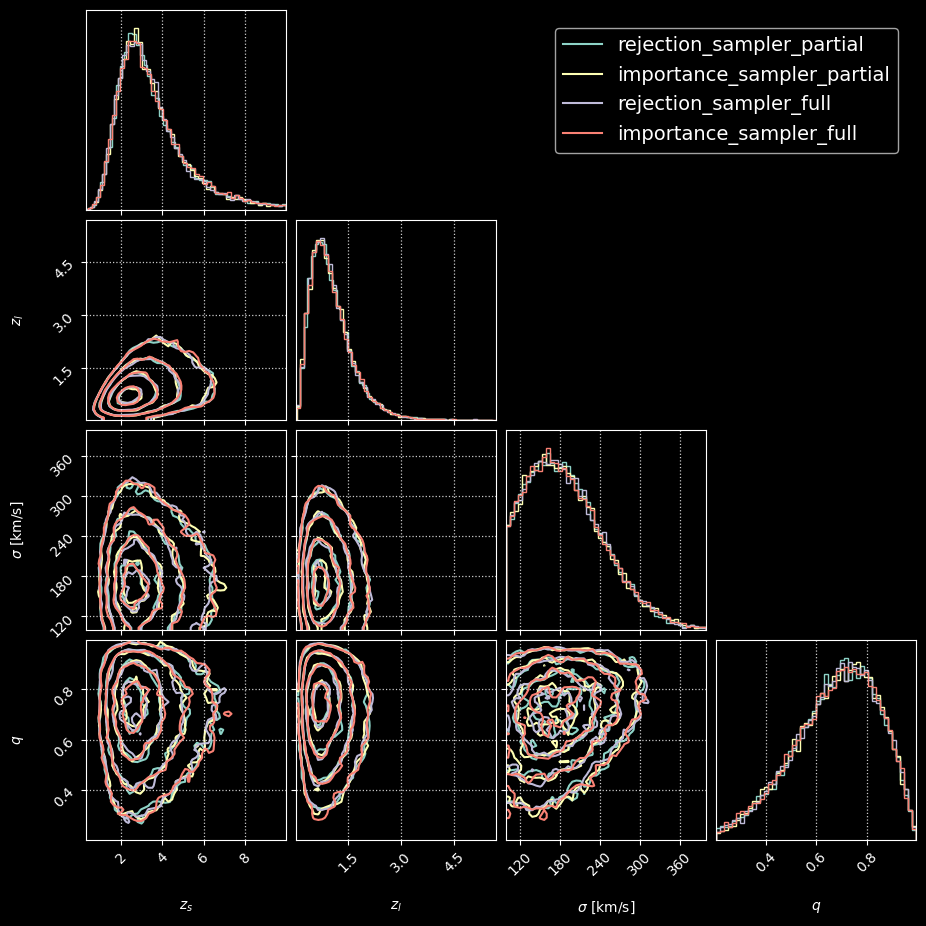

In [8]:
import corner
import matplotlib.lines as mlines

param_names = ['zs', 'zl', 'sigma', 'q']
labels = ['$z_s$', '$z_l$', r'$\sigma$ [km/s]', '$q$']

samples1 = np.stack([param1[p] for p in param_names], axis=1)
samples2 = np.stack([param2[p] for p in param_names], axis=1)
samples3 = np.stack([param3[p] for p in param_names], axis=1)
samples4 = np.stack([param4[p] for p in param_names], axis=1)

fig = corner.corner(
    samples1, 
    labels=labels, 
    color='C0', 
    alpha=0.5,
    plot_density=False, 
    plot_datapoints=False, 
    bins=50,
    smooth=0.8,
    hist_kwargs={'density': True}
)

corner.corner(
    samples2, 
    labels=labels, 
    color='C1', 
    alpha=0.5,
    fig=fig,
    plot_density=False, 
    plot_datapoints=False, 
    bins=50,
    smooth=0.8,
    hist_kwargs={'density': True}
)

corner.corner(
    samples3, 
    labels=labels, 
    color='C2', 
    alpha=0.5,
    fig=fig,
    plot_density=False, 
    plot_datapoints=False, 
    bins=50,
    smooth=0.8,
    hist_kwargs={'density': True}
)

corner.corner(
    samples4, 
    labels=labels, 
    color='C3', 
    alpha=0.5,
    fig=fig,
    plot_density=False, 
    plot_datapoints=False, 
    bins=50,
    smooth=0.8,
    hist_kwargs={'density': True}
)

# Add grid lines
for ax in fig.axes:
    ax.set_axisbelow(False)

    ax.grid(
        True,
        which='major',
        linestyle=':',
        linewidth=0.9,
        alpha=0.8,
        zorder=10,
    )

# Add legend
green_line = mlines.Line2D([], [], color='C0', label='rejection_sampler_partial')
blue_line = mlines.Line2D([], [], color='C1', label='importance_sampler_partial')
red_line = mlines.Line2D([], [], color='C2', label='rejection_sampler_full')
orange_line = mlines.Line2D([], [], color='C3', label='importance_sampler_full')
fig.legend(handles=[green_line, blue_line, red_line, orange_line], loc='upper right', 
           bbox_to_anchor=(0.95, 0.95), fontsize=14)
plt.show()


## KS Score

In [10]:
from ler.utils import KStest

ks_score = KStest(param3, param4)
print('#--------------------------------#')
print('KS Score between rejection_sampler_full and importance_sampler_full')
print('#--------------------------------#')
for key, value in ks_score.items(): 
    print(f'{key}: {value}')

ks_score = KStest(param3, param2)
print('#--------------------------------#')
print('KS Score between rejection_sampler_full and importance_sampler_partial')
print('#--------------------------------#') 
for key, value in ks_score.items():
    print(f'{key}: {value}')

ks_score = KStest(param3, param1)
print('#--------------------------------#')
print('KS Score between rejection_sampler_full and rejection_sampler_partial')
print('#--------------------------------#')
for key, value in ks_score.items():
    print(f'{key}: {value}')

#--------------------------------#
KS Score between rejection_sampler_full and importance_sampler_full
#--------------------------------#
q: {'D': 0.008450000000000013, 'pvalue': 0.47040522912456817, 'n1': 20000, 'n2': 20000}
sigma: {'D': 0.005749999999999977, 'pvalue': 0.8936027987210846, 'n1': 20000, 'n2': 20000}
zl: {'D': 0.012299999999999978, 'pvalue': 0.0962314629443114, 'n1': 20000, 'n2': 20000}
zs: {'D': 0.01824999999999999, 'pvalue': 0.002527269779190028, 'n1': 20000, 'n2': 20000}
#--------------------------------#
KS Score between rejection_sampler_full and importance_sampler_partial
#--------------------------------#
q: {'D': 0.006900000000000017, 'pvalue': 0.7250736496496843, 'n1': 20000, 'n2': 20000}
sigma: {'D': 0.005699999999999983, 'pvalue': 0.8994451986334463, 'n1': 20000, 'n2': 20000}
zl: {'D': 0.010750000000000037, 'pvalue': 0.19666940887988715, 'n1': 20000, 'n2': 20000}
zs: {'D': 0.006450000000000011, 'pvalue': 0.797170795694494, 'n1': 20000, 'n2': 20000}
#----------